In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import pickle

# paths
current_dir = Path.cwd()
project_root = current_dir.parent

# load customer features
df = pd.read_csv(f"{project_root}/Data/customer_features.csv")

# load trained model
model_path = f"{project_root}/models/clv_model.pkl"
with open(model_path, "rb") as f:
    model = pickle.load(f)

df.head()

,customer_id,num_orders,total_spent,avg_order_value,order_value_std,first_order_date,last_order_date,country,recency_days,customer_age_days,frequency,monetary,months_active,purchase_growth
0,12346.0,1,77183.60,77183.600000,NaN,2011-01-18 10:01:00,2011-01-18 10:01:00,United Kingdom,325,0,1,77183.60,1,0.000000
1,12347.0,7,4310.00,23.681319,23.289902,2010-12-07 14:57:00,2011-12-07 15:52:00,Iceland,1,365,7,4310.00,7,-0.683189
2,12348.0,4,1797.24,57.975484,48.514857,2010-12-16 19:09:00,2011-09-25 13:13:00,Finland,74,282,4,1797.24,4,-0.652047
3,12349.0,1,1757.55,24.076027,34.655913,2011-11-21 09:51:00,2011-11-21 09:51:00,Italy,18,0,1,1757.55,1,0.000000
4,12350.0,1,334.40,19.670588,7.275538,2011-02-02 16:01:00,2011-02-02 16:01:00,Norway,309,0,1,334.40,1,0.000000


In [2]:
features = [
    "num_orders",
    "avg_order_value",
    "order_value_std",
    "recency_days",
    "customer_age_days",
    "months_active",
    "purchase_growth"
]

X = df[features].fillna(0)

In [9]:
preds_log = model.predict(X)
df["predicted_clv"] = np.expm1(preds_log)

df[["customer_id", "predicted_clv"]].head()

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4338 entries, 0 to 4337
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   customer_id        4338 non-null   float64 
 1   num_orders         4338 non-null   int64   
 2   total_spent        4338 non-null   float64 
 3   avg_order_value    4338 non-null   float64 
 4   order_value_std    4267 non-null   float64 
 5   first_order_date   4338 non-null   object  
 6   last_order_date    4338 non-null   object  
 7   country            4338 non-null   object  
 8   recency_days       4338 non-null   int64   
 9   customer_age_days  4338 non-null   int64   
 10  frequency          4338 non-null   int64   
 11  monetary           4338 non-null   float64 
 12  months_active      4338 non-null   int64   
 13  purchase_growth    4338 non-null   float64 
 14  predicted_clv      4338 non-null   float64 
 15  CLV_Segment        4338 non-null   category
dtypes: cat

In [7]:
df["CLV_Segment"] = pd.cut(
    df["predicted_clv"],
    bins=[0, 500, 1500, 5000, np.inf],
    labels=["Low", "Medium", "High", "VIP"]
)

df["CLV_Segment"].value_counts()

CLV_Segment
Low       1787
Medium    1490
High       846
VIP        215
Name: count, dtype: int64

In [10]:
segment_profile = df.groupby("CLV_Segment").agg(
    customers=("customer_id", "count"),
    avg_clv=("predicted_clv", "mean"),
    avg_orders=("num_orders", "mean"),
    avg_order_value=("avg_order_value", "mean")
).round(2)

segment_profile

C:\Users\sneha\AppData\Local\Temp\ipykernel_24712\734161933.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_profile = df.groupby("CLV_Segment").agg(


,customers,avg_clv,avg_orders,avg_order_value
CLV_Segment,,,,
Low,1787,290.28,1.21,23.49
Medium,1490,866.21,3.03,28.77
High,846,2540.49,7.71,46.68
VIP,215,15284.64,24.76,800.78


In [11]:
segment_revenue = df.groupby("CLV_Segment")["predicted_clv"].sum().sort_values(ascending=False)

segment_revenue

C:\Users\sneha\AppData\Local\Temp\ipykernel_24712\549235908.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_revenue = df.groupby("CLV_Segment")["predicted_clv"].sum().sort_values(ascending=False)


CLV_Segment
VIP       3.286197e+06
High      2.149255e+06
Medium    1.290652e+06
Low       5.187366e+05
Name: predicted_clv, dtype: float64

In [12]:
output_path = f"{project_root}/Data/customer_clv_segments.csv"
df.to_csv(output_path, index=False)

print("Saved:", output_path)

Saved: c:\Users\sneha\OneDrive\Documents\CLV_Project/Data/customer_clv_segments.csv


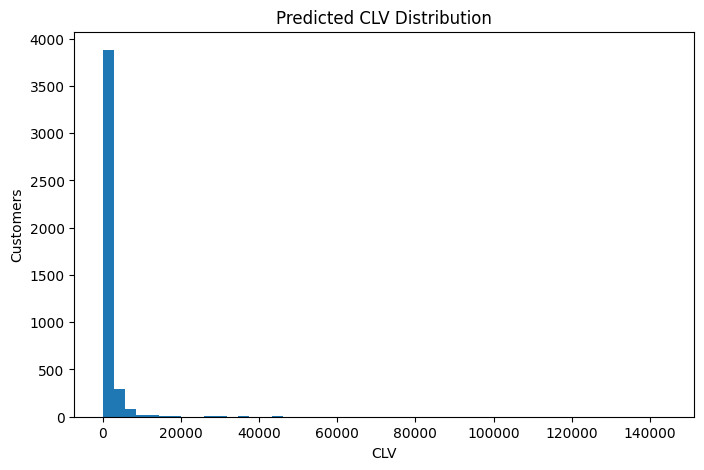

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df["predicted_clv"], bins=50)
plt.title("Predicted CLV Distribution")
plt.xlabel("CLV")
plt.ylabel("Customers")
plt.show()